# Exploratoty Data Analysis

Note: This notebook's sole purpose is to enlighten the reader on the behind the results obtained for the univariate and bivariate analysis. Interpratation of the results wil only be done in the paper.

# Non Stadard Library Instalations

In [108]:
#%pip install scipy
%pip install statsmodels


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Imports

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import t
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.stats.diagnostic import acorr_ljungbox, linear_reset


# Data Prep

In order to prepare our data, we restrict our cleaned and processed data to only the selected variables.

In [110]:
Data = pd.read_csv("/Users/mathisvernier/Markovian-Embedding/data/processed/NS_data.csv")
SELECTED = ["RPI", "DPCERA3M086SBEA", "UNRATE", "UEMPMEAN", "PERMIT",
            "ISRATIOx", "M1SL", "REALLN", "S&P PE ratio", "GS10",
            "EXSZUSx", "CUSR0000SAC", "CES2000000008"]

EDA_data = Data[SELECTED].copy()
EDA_data

,RPI,DPCERA3M086SBEA,UNRATE,UEMPMEAN,PERMIT,ISRATIOx,M1SL,REALLN,S&P PE ratio,GS10,EXSZUSx,CUSR0000SAC,CES2000000008
0,0.001147,0.004361,-0.4,-0.4,-0.003670,0.020662,-1.429082e-03,-0.001609,-0.052881,-0.23,0.002493,-0.002990,0.003853
1,0.001877,0.014089,0.6,-0.1,-0.130385,0.030993,-5.109339e-07,0.000612,-0.021170,-0.24,-0.000161,0.005979,0.030131
2,0.003465,0.015302,-0.2,-0.4,0.061917,-0.010331,-7.165876e-04,-0.001608,0.003859,0.03,0.000438,-0.000009,0.035876
3,0.002405,-0.020351,-0.1,-0.7,0.034820,0.030993,1.431639e-03,-0.001945,-0.011263,0.07,-0.003301,-0.002981,0.041620
4,0.000764,-0.000250,0.3,0.0,-0.093601,0.010331,0.000000e+00,-0.000784,0.034284,-0.20,-0.002199,0.000000,-0.011429
...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,0.001249,-0.001198,0.1,-0.7,-0.004118,-0.010000,-1.235419e-03,0.001799,-0.000587,-0.18,-0.006840,-0.003188,-0.000831
781,0.006506,0.007758,0.1,1.5,0.018399,-0.010000,-1.957339e-03,-0.001806,-0.069893,-0.17,-0.022161,-0.005432,0.001080
782,0.007353,0.001399,0.0,0.4,-0.040653,0.000000,5.353561e-03,0.000628,-0.068430,0.00,-0.058131,0.004319,0.000527
783,-0.005669,-0.001399,0.0,-1.4,-0.019887,0.010000,-4.218339e-03,0.001122,0.068349,0.14,-0.004568,-0.001082,-0.001097


# Univariate Analysis

For this we will focus on the 13 selected variables individually.

       Variable   n   Mean  Std Dev    Min   Max  Skewness  Kurtosis  ACF(1)
            RPI 785  0.002    0.005 -0.033 0.042    -0.010    14.674   0.005
DPCERA3M086SBEA 785  0.003    0.006 -0.025 0.053     1.407    12.801  -0.009
         UNRATE 785 -0.014    0.208 -1.800 0.900    -1.333    13.563   0.260
       UEMPMEAN 785  0.024    0.767 -3.600 3.900     0.115     3.653  -0.046
         PERMIT 785  0.000    0.060 -0.274 0.292    -0.192     2.776  -0.079
       ISRATIOx 785 -0.001    0.019 -0.180 0.114    -1.177    14.921   0.075
           M1SL 785  0.000    0.009 -0.068 0.061     0.403    11.824  -0.295
         REALLN 785  0.000    0.004 -0.026 0.032     0.540    12.371  -0.215
   S&P PE ratio 785  0.001    0.046 -0.222 0.235    -0.115     5.339   0.495
           GS10 785 -0.000    0.273 -1.760 1.610    -0.418     6.158   0.305
        EXSZUSx 785 -0.002    0.025 -0.087 0.117    -0.147     1.921   0.267
    CUSR0000SAC 785  0.000    0.005 -0.035 0.025    -0.449     6.425  -0.232

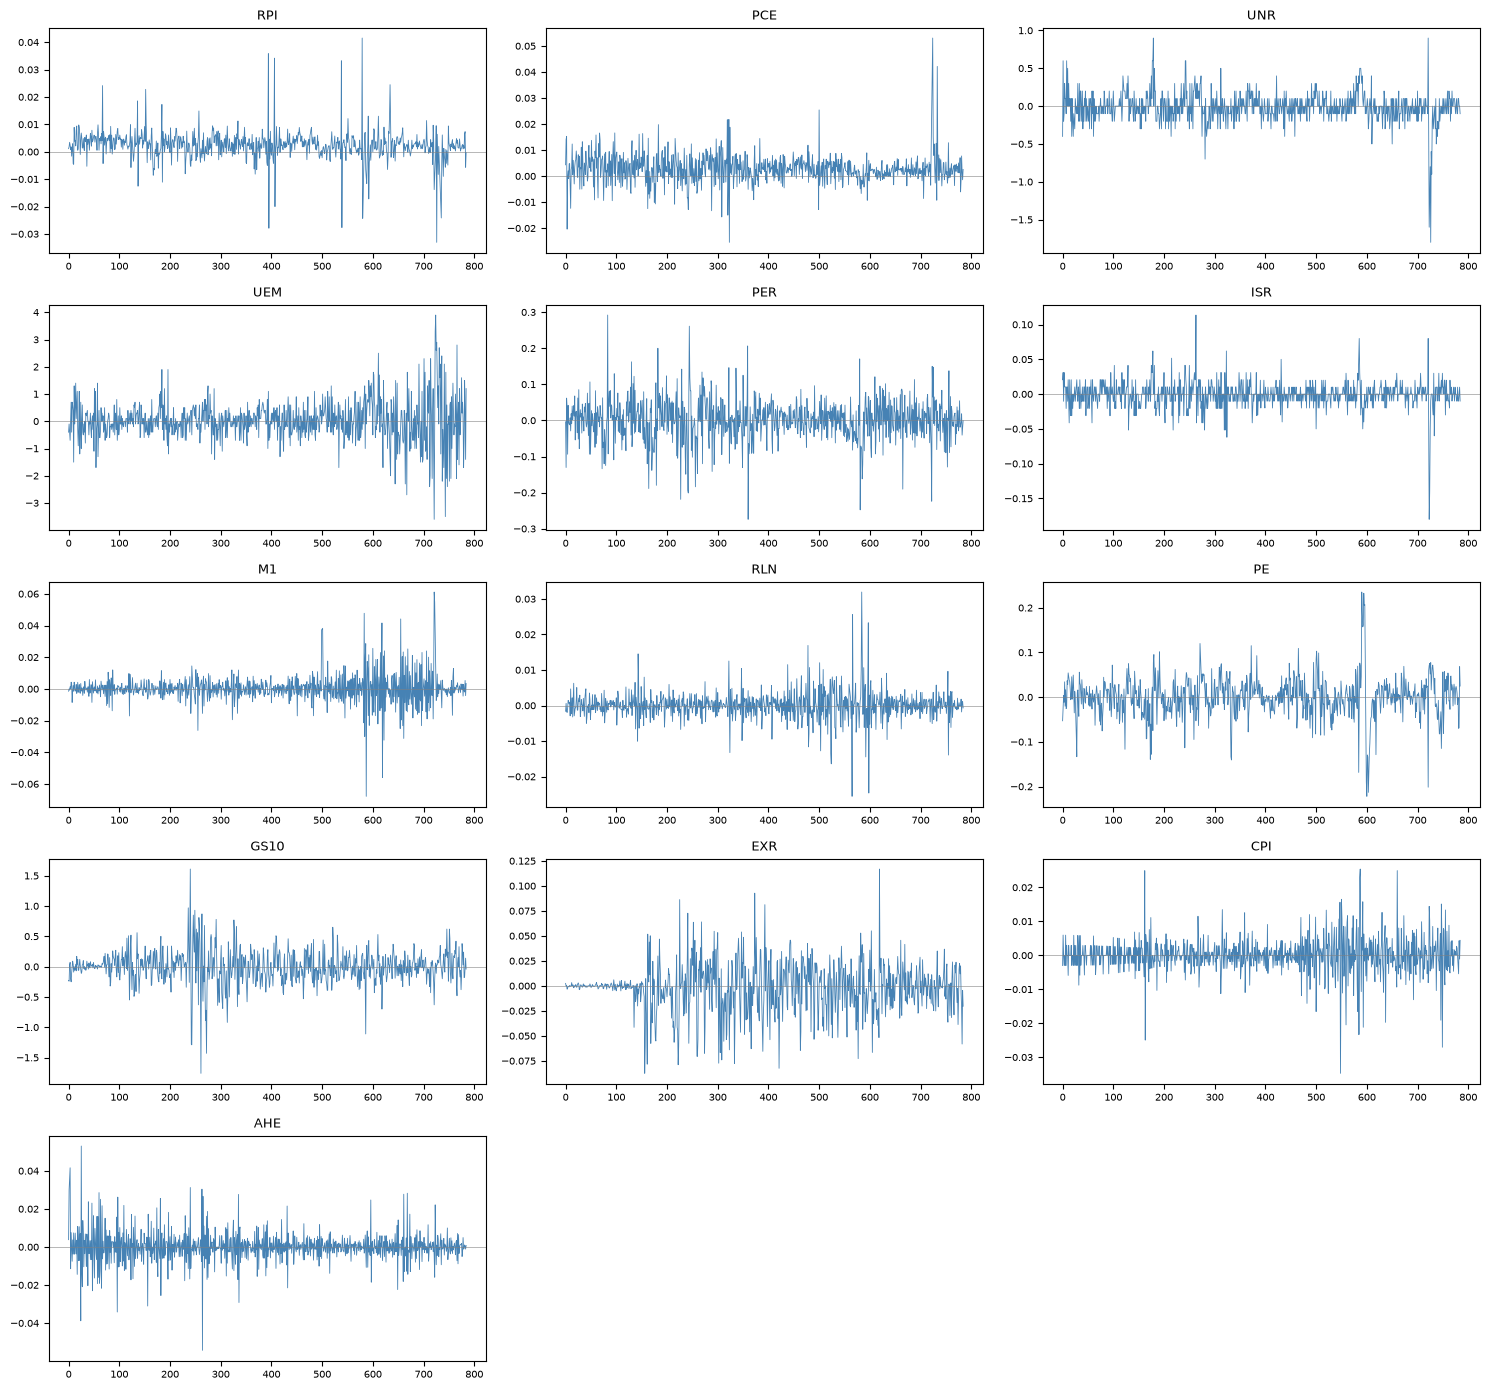

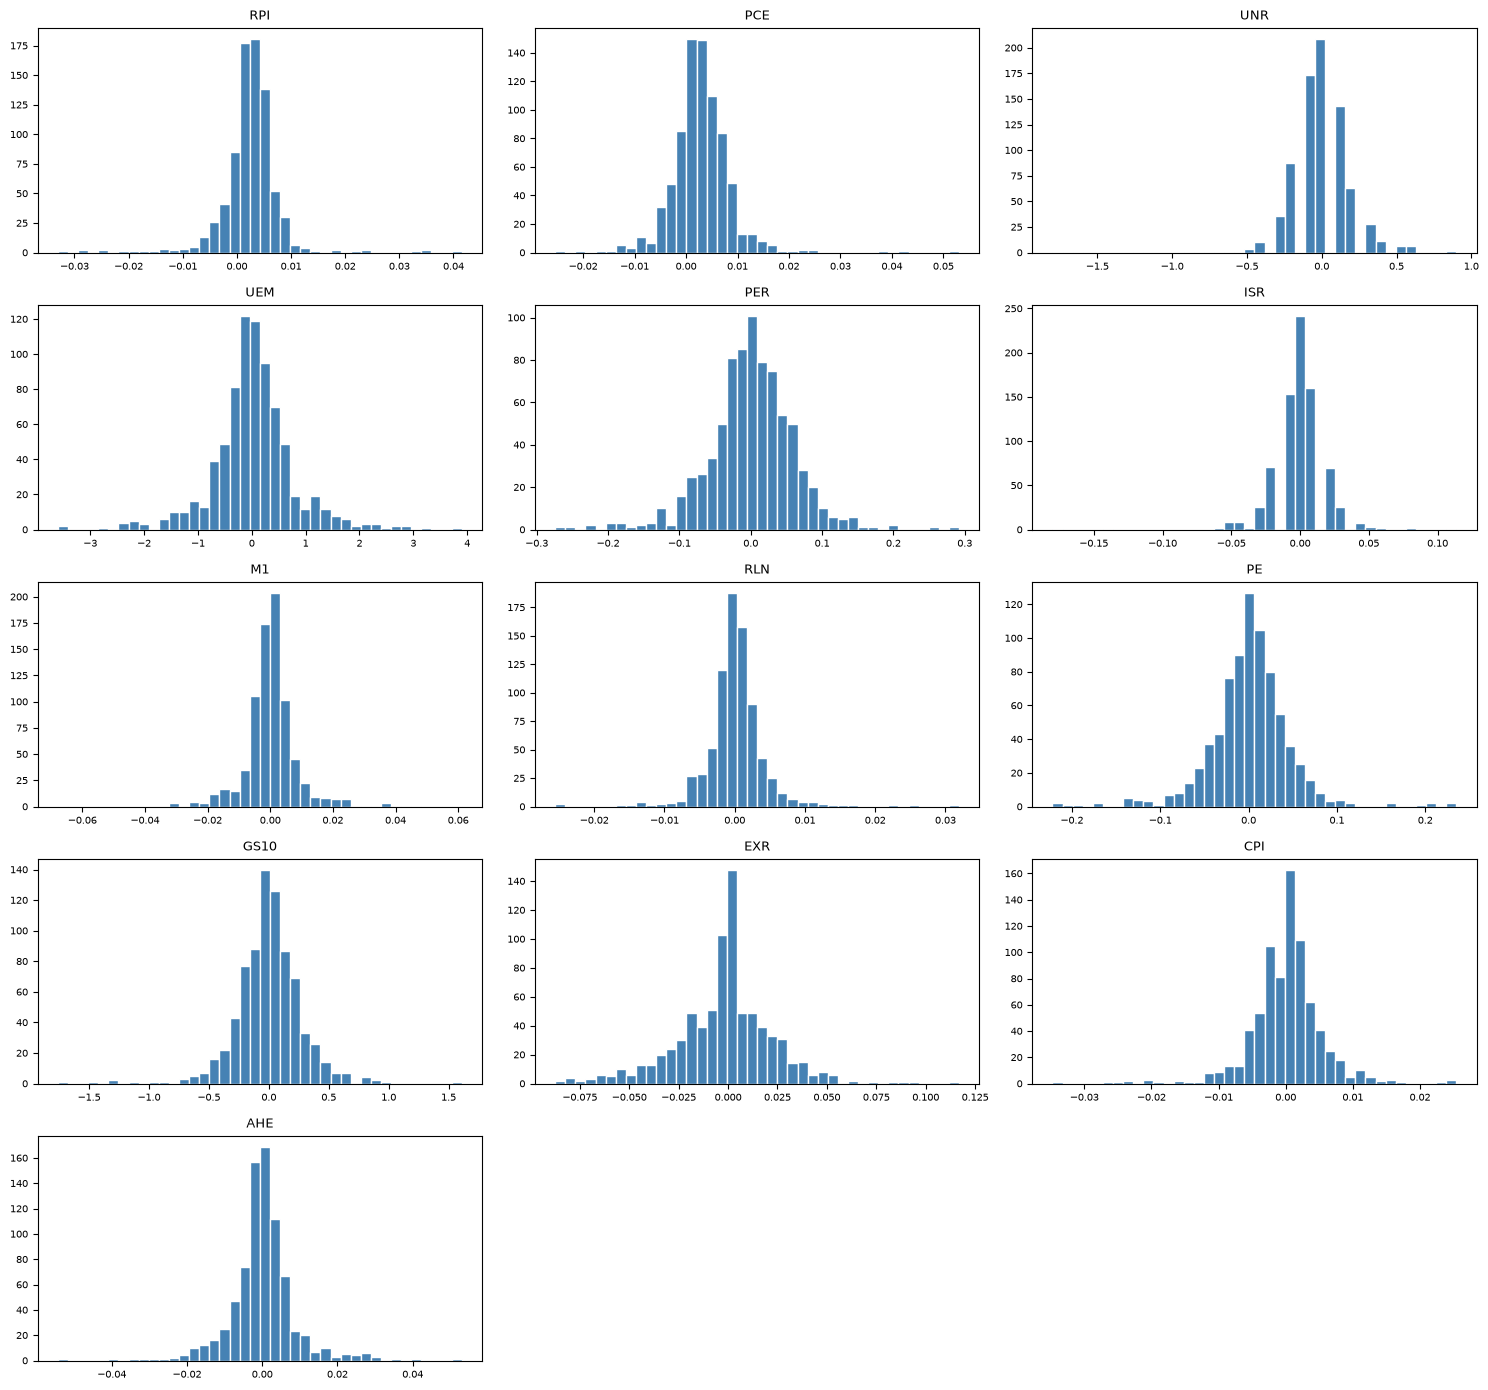

In [111]:
# ---------- Univariate Analysis ----------
results = []
for var in SELECTED:
    s = EDA_data[var].dropna()
    n = len(s)

    mean = s.mean()
    std = s.std()
    minimum = s.min()
    maximum = s.max()
    skewness = s.skew()
    kurtosis = s.kurt()          # excess kurtosis, pandas default (0 = normal)
    acf1 = s.autocorr(lag=1)

  

    results.append({
        "Variable": var,
        "n": n,
        "Mean": round(mean, 3),
        "Std Dev": round(std, 3),
        "Min": round(minimum, 3),
        "Max": round(maximum, 3),
        "Skewness": round(skewness, 3),
        "Kurtosis": round(kurtosis, 3),
        "ACF(1)": round(acf1, 3),

    })

univariate_table = pd.DataFrame(results)
print(univariate_table.to_string(index=False))


fig, axes = plt.subplots(5, 3, figsize=(15, 14))
for ax, var in zip(axes.flat, SELECTED):
    ax.plot(EDA_data.index, EDA_data[var], lw=.6, color="steelblue")
    ax.axhline(0, color="gray", lw=.4)
    ax.set_title(short_names[var], fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(SELECTED):]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig("fig_univariate_timeseries.png", dpi=140)


fig, axes = plt.subplots(5, 3, figsize=(15, 14))
for ax, var in zip(axes.flat, SELECTED):
    ax.hist(EDA_data[var].dropna(), bins=40, color="steelblue", edgecolor="white")
    ax.set_title(short_names[var], fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(SELECTED):]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig("fig_univariate_histograms.png", dpi=140)

print("\nsaved fig_univariate_timeseries.png and fig_univariate_histograms.png")

# Bivariate Analysis

Now we will turn our attention to the bivariate relationships discussed in the paper:


However before we restrict ourselves to only these 4 pairs of variables we will look at some general characteristics of all the variable pairs. We first look at the correlation between all variables which results into the table ...  found in the appendix


In [112]:
results = []

#pair generation
for var1, var2 in combinations(SELECTED, 2):
    correlation = EDA_data[var1].corr(EDA_data[var2])
    results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "Correlation": correlation
    })

correlation_table = pd.DataFrame(results)
correlation_table["Correlation"] = (
    correlation_table["Correlation"].round(3)
)

print(correlation_table)



     Variable 1       Variable 2  Correlation
0           RPI  DPCERA3M086SBEA        0.129
1           RPI           UNRATE       -0.006
2           RPI         UEMPMEAN       -0.035
3           RPI           PERMIT        0.057
4           RPI         ISRATIOx       -0.021
..          ...              ...          ...
73         GS10      CUSR0000SAC        0.055
74         GS10    CES2000000008        0.008
75      EXSZUSx      CUSR0000SAC       -0.057
76      EXSZUSx    CES2000000008       -0.000
77  CUSR0000SAC    CES2000000008        0.012

[78 rows x 3 columns]


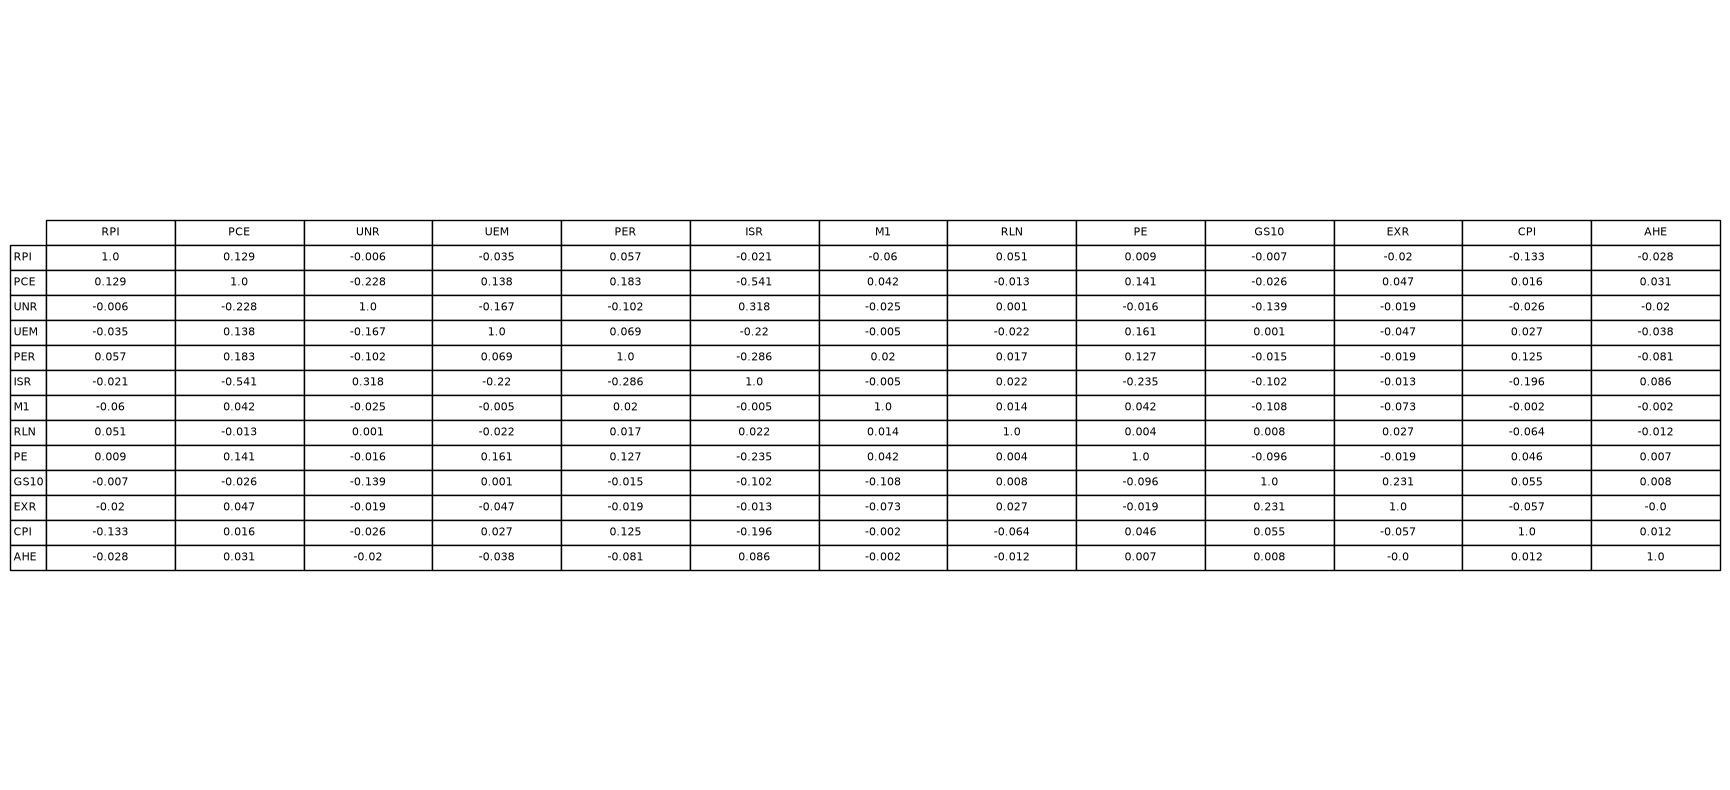

In [113]:
#same thing but now in a table and with smaller names so that it fits

short_names = {
    "RPI": "RPI",
    "DPCERA3M086SBEA": "PCE",
    "UNRATE": "UNR",
    "UEMPMEAN": "UEM",
    "PERMIT": "PER",
    "ISRATIOx": "ISR",
    "M1SL": "M1",
    "REALLN": "RLN",
    "S&P PE ratio": "PE",
    "GS10": "GS10",
    "EXSZUSx": "EXR",
    "CUSR0000SAC": "CPI",
    "CES2000000008": "AHE"
}

EDA_data_2 = Data[SELECTED].copy()
EDA_data_2 = EDA_data_2.rename(columns=short_names)
correlation_matrix = EDA_data_2.corr().round(3)

fig, ax = plt.subplots(figsize=(18, 10))
ax.axis("off")


table = ax.table(
    cellText=correlation_matrix.round(3).values,
    rowLabels=correlation_matrix.index,
    colLabels=correlation_matrix.columns,
    cellLoc="center",
    loc="center"
)


table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)




Now that we have a general overview of the correlation between all variable pairs, we will now focus on the pair only. We will again first generate a table with their corralations as well as testing them for statistical significance using the t-stat as wella s the p value. We will than move to lagged correlation and finally cointegration

In [114]:
#same code as above but restricted to the 4 pairs
#relationships
relationships = [
    ("UNRATE", "CES2000000008"),
    ("PERMIT", "ISRATIOx"),
    ("RPI", "DPCERA3M086SBEA"),
    ("S&P PE ratio", "GS10")
]

results = []


for var1, var2 in relationships:

    correlation = Data[var1].corr(Data[var2])

    results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "Correlation": correlation
    })

correlation_table = pd.DataFrame(results)

correlation_table["Correlation"] = (
    correlation_table["Correlation"].round(3)
)


print(correlation_table.to_string(index=False))

  Variable 1      Variable 2  Correlation
      UNRATE   CES2000000008       -0.020
      PERMIT        ISRATIOx       -0.286
         RPI DPCERA3M086SBEA        0.129
S&P PE ratio            GS10       -0.096


In [115]:
results = []

for var1, var2 in relationships:

    pair_data = Data[[var1, var2]]
    n = len(pair_data)

    #correlation
    r = pair_data[var1].corr(
        pair_data[var2],
        method="pearson"
    )

    #t-stat
    t_statistic = r * (
        (n - 2) / (1 - r**2)
    )**0.5

    degrees_freedom = n - 2

    #two-sided p value
    p_value = 2 * t.sf(
        abs(t_statistic),
        degrees_freedom
    )

    #significance at the 5% level
    if p_value < 0.05:
        result = "Significant"
    else:
        result = "Not significant"

    results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "n": n,
        "Correlation r": round(r, 3),
        "t-statistic": round(t_statistic, 3),
        "p-value": round(p_value, 4),
        "Result": result
    })

correlation_test_table = pd.DataFrame(results)

print(
    correlation_test_table.to_string(
        index=False
    )
)

  Variable 1      Variable 2   n  Correlation r  t-statistic  p-value          Result
      UNRATE   CES2000000008 785         -0.020       -0.563   0.5735 Not significant
      PERMIT        ISRATIOx 785         -0.286       -8.352   0.0000     Significant
         RPI DPCERA3M086SBEA 785          0.129        3.636   0.0003     Significant
S&P PE ratio            GS10 785         -0.096       -2.692   0.0073     Significant


For cointegration we will need the raw non stationary and thus non transformed data. since cointigration only work on non stationary new data prep:

In [116]:
coin_data = pd.read_csv("/Users/mathisvernier/Markovian-Embedding/data/processed/UT_NS_data.csv")

In [117]:

all_vars = sorted(set(v for pair in relationships for v in pair))

adf_results = []
for var in all_vars:
    series = coin_data[var].dropna()
    stat, pvalue, *_ = adfuller(series, autolag="AIC")
    adf_results.append({"Variable": var, "ADF stat": round(stat, 3),
                         "p-value": round(pvalue, 4),
                         "I(1) candidate": "Yes" if pvalue > 0.05 else "No (already stationary)"})
adf_table = pd.DataFrame(adf_results)
print(adf_table.to_string(index=False))
 

eg_results = []
for var1, var2 in relationships:
    s1 = coin_data[var1].dropna()
    s2 = coin_data[var2].dropna()
    common_idx = s1.index.intersection(s2.index)
    s1, s2 = s1.loc[common_idx], s2.loc[common_idx]
 
    eg_stat, eg_pvalue, crit_values = coint(s1, s2)
    result = "Cointegrated" if eg_pvalue < 0.05 else "Not cointegrated"
    eg_results.append({
        "Variable 1": var1, "Variable 2": var2, "n": len(common_idx),
        "EG statistic": round(eg_stat, 3), "p-value": round(eg_pvalue, 4),
        "Result": result
    })
eg_table = pd.DataFrame(eg_results)
print(eg_table.to_string(index=False))
 

       Variable  ADF stat  p-value          I(1) candidate
  CES2000000008     2.209   0.9989                     Yes
DPCERA3M086SBEA     3.187   1.0000                     Yes
           GS10    -1.254   0.6500                     Yes
       ISRATIOx    -2.415   0.1376                     Yes
         PERMIT    -4.197   0.0007 No (already stationary)
            RPI     2.959   1.0000                     Yes
   S&P PE ratio    -4.169   0.0007 No (already stationary)
         UNRATE    -3.369   0.0121 No (already stationary)
  Variable 1      Variable 2   n  EG statistic  p-value       Result
      UNRATE   CES2000000008 786        -3.414   0.0408 Cointegrated
      PERMIT        ISRATIOx 786        -4.124   0.0047 Cointegrated
         RPI DPCERA3M086SBEA 786        -3.897   0.0100 Cointegrated
S&P PE ratio            GS10 786        -5.532   0.0000 Cointegrated


# Autocorrelation function for the memory effect

In [118]:
results = []
for var in SELECTED:
    s = EDA_data[var].dropna()
    n = len(s)

    acf1 = s.autocorr(lag=1)
    acf3 = s.autocorr(lag=3)
    acf6 = s.autocorr(lag=6)
    acf12 = s.autocorr(lag=12)
    acf24 = s.autocorr(lag=24)
    acf60 = s.autocorr(lag=60)
    acf120 = s.autocorr(lag=120)
    acf240 = s.autocorr(lag=240)
    acf600 = s.autocorr(lag=600)
    

    results.append({
        "Variable": var,
        "ACF(1)": round(acf1, 3),
        "ACF(3)": round(acf3, 3),
        "ACF(6)": round(acf6, 3),
        "ACF(12)": round(acf12, 3),
        "ACF(24)": round(acf24, 3),
        "ACF(60)": round(acf60, 3),
        "ACF(120)": round(acf120, 3),
        "ACF(240)": round(acf240, 3),
        "ACF(600)": round(acf600, 3),

    })

auto_corr = pd.DataFrame(results)
print(auto_corr.to_string(index=False))


       Variable  ACF(1)  ACF(3)  ACF(6)  ACF(12)  ACF(24)  ACF(60)  ACF(120)  ACF(240)  ACF(600)
            RPI   0.005   0.060   0.085    0.212    0.049    0.059     0.011     0.065    -0.001
DPCERA3M086SBEA  -0.009   0.095   0.078    0.047   -0.095    0.020    -0.004     0.008     0.023
         UNRATE   0.260   0.287   0.145   -0.002   -0.087   -0.004     0.059    -0.032    -0.119
       UEMPMEAN  -0.046   0.116   0.092   -0.089   -0.109    0.017     0.043     0.050     0.030
         PERMIT  -0.079   0.027   0.023   -0.117   -0.117   -0.036    -0.035     0.008    -0.023
       ISRATIOx   0.075   0.101   0.036   -0.126   -0.164    0.023    -0.034    -0.046     0.071
           M1SL  -0.295   0.176   0.086    0.098   -0.228    0.141    -0.009     0.061     0.113
         REALLN  -0.215   0.039   0.050    0.036    0.008    0.007    -0.097    -0.038    -0.173
   S&P PE ratio   0.495   0.257   0.021   -0.129   -0.071   -0.025     0.029    -0.034    -0.052
           GS10   0.305  -0.03

In [119]:
reset_results = []
for var in SELECTED:
    s = EDA_data[var].dropna()
    y = s.iloc[1:].values
    x = s.iloc[:-1].values
    X_design = sm.add_constant(x)
    model = sm.OLS(y, X_design).fit()
    reset = linear_reset(model, power=3, test_type="fitted", use_f=True)
    reset_results.append({"Variable": var,
                           "RESET F-stat": round(reset.fvalue, 3),
                           "p-value": round(reset.pvalue, 4),
                           "Nonlinear": "Yes" if reset.pvalue < 0.05 else "No"})
reset_table = pd.DataFrame(reset_results)
print(reset_table.to_string(index=False))

       Variable  RESET F-stat  p-value Nonlinear
            RPI        81.377   0.0000       Yes
DPCERA3M086SBEA        19.750   0.0000       Yes
         UNRATE         9.545   0.0001       Yes
       UEMPMEAN        17.175   0.0000       Yes
         PERMIT         5.482   0.0043       Yes
       ISRATIOx        31.163   0.0000       Yes
           M1SL        59.231   0.0000       Yes
         REALLN         5.312   0.0051       Yes
   S&P PE ratio        15.705   0.0000       Yes
           GS10         2.244   0.1068        No
        EXSZUSx         0.809   0.4456        No
    CUSR0000SAC        11.316   0.0000       Yes
  CES2000000008        15.872   0.0000       Yes
